# Runtime safeguards: avoiding the n=12 footgun

`exhaustive_generate(n_nodes, groups)` enumerates every distinct connected molecular graph on `n_nodes` nodes from a library of `n_colors = len(groups)` building blocks. The size of that search space scales as

$$
\text{vcolg lines} \le A001349(n) \cdot n_{\text{colors}}^{n}
$$

where `A001349(n)` is [the number of connected simple graphs on n vertices](https://oeis.org/A001349). That sequence is double-exponential: at n=10 it's 11.7 million, at n=12 it's 155 *billion*. A user who pastes

```python
exhaustive_generate(12, my_four_groups)
```

into a notebook expecting it to "just run" can lock up their laptop, fill swap, and lose unsaved work.

Grouper has a Python-level pre-flight check that raises `GrouperResourceLimitError` *before* any heavy work starts when the configuration is too big. This notebook covers:

1. The estimator that powers the check, so you can plan ahead
2. What the safeguards do at each scale (silent / warn / raise / refuse)
3. The two escape hatches (`confirm=True`, `max_vcolg_lines=N`)
4. **Strategies for tackling larger spaces** when a single machine isn't enough — multi-processing, random sampling, constraint-based filtering, file-based streaming, and pointers to where you'd go for distributed compute.

Estimated runtime: under 5 seconds (the demo runs only safe cases).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Grouper import Group, GrouperResourceLimitError, exhaustive_generate, random_generate
from Grouper._safeguards import estimate_vcolg_lines, check_resource_limits

## 1. The estimator

`estimate_vcolg_lines(n_nodes, n_colors)` returns an upper bound on how many lines vcolg will emit. It uses an OEIS A001349 lookup table (n = 1..10) and the simple formula above, so it's instantaneous — no need to actually run geng or vcolg. Returns `None` for n > 10 (treated as intractable).

Use this to plan a run before launching it.

In [2]:
rows = []
for n in range(2, 11):
    rows.append({
        "n_nodes":      n,
        "c=2":          f"{estimate_vcolg_lines(n, 2):>15,}",
        "c=4":          f"{estimate_vcolg_lines(n, 4):>15,}",
        "c=8":          f"{estimate_vcolg_lines(n, 8):>18,}",
        "c=16":         f"{estimate_vcolg_lines(n, 16):>21,}",
    })
rows.append({"n_nodes": 11, "c=2": "intractable", "c=4": "intractable",
             "c=8": "intractable", "c=16": "intractable"})
rows.append({"n_nodes": 12, "c=2": "intractable", "c=4": "intractable",
             "c=8": "intractable", "c=16": "intractable"})

df = pd.DataFrame(rows)
print("Upper-bound vcolg-line estimates by n_nodes × n_colors:")
print(df.to_string(index=False))

Upper-bound vcolg-line estimates by n_nodes × n_colors:
 n_nodes             c=2                c=4                    c=8                       c=16
       2               4                 16                     64                        256
       3              16                128                  1,024                      8,192
       4              96              1,536                 24,576                    393,216
       5             672             21,504                688,128                 22,020,096
       6           7,168            458,752             29,360,128              1,879,048,192
       7         109,184         13,975,552          1,788,870,656            228,975,443,968
       8       2,845,952        728,563,712        186,512,310,272         47,747,151,429,632
       9     133,672,960     68,440,555,520     35,041,564,426,240     17,941,280,986,234,880
      10  11,997,768,704 12,285,715,152,896 12,580,572,316,565,504 12,882,506,052,163,076,096
    

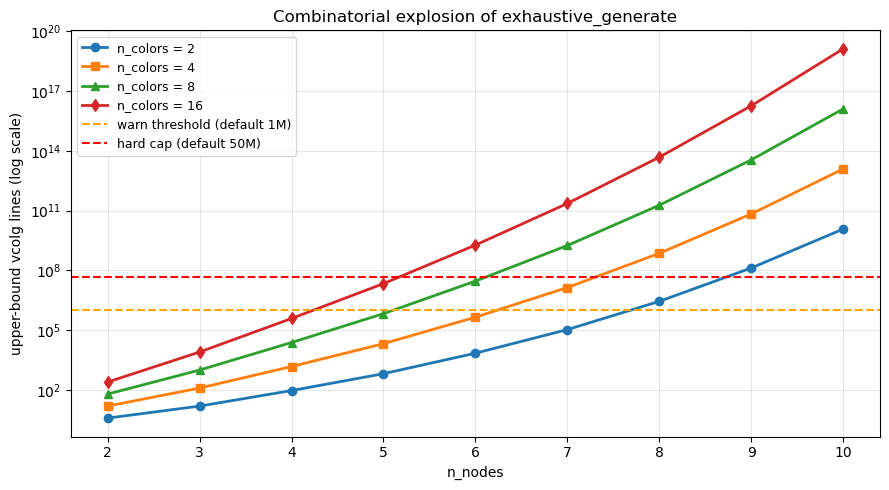

In [3]:
# Visualize the double-exponential growth. Log y-axis because the
# numbers span ~12 orders of magnitude as n goes from 2 to 10.
fig, ax = plt.subplots(figsize=(9, 5))
ns = np.arange(2, 11)
for c, marker in zip([2, 4, 8, 16], ["o", "s", "^", "d"]):
    estimates = [estimate_vcolg_lines(int(n), c) for n in ns]
    ax.semilogy(ns, estimates, marker=marker, label=f"n_colors = {c}", linewidth=2)

# Default thresholds — handy reference lines.
ax.axhline(1_000_000, color="orange", linestyle="--",
           label="warn threshold (default 1M)")
ax.axhline(50_000_000, color="red", linestyle="--",
           label="hard cap (default 50M)")
ax.set_xlabel("n_nodes")
ax.set_ylabel("upper-bound vcolg lines (log scale)")
ax.set_title("Combinatorial explosion of exhaustive_generate")
ax.grid(True, alpha=0.3, which="both")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

Two things to notice on the chart:

1. **The curves climb fast** — adding two nodes pushes the line count up by 2–3 orders of magnitude. Every additional node is roughly an order of magnitude more work.
2. **The hard cap (red dashed line, 50M) is hit early**: at `n_colors = 4` it kicks in around n=8; at `n_colors = 16` it kicks in around n=6. The hard cap corresponds to roughly 3 hours of wall-time on typical multi-core hardware — if you're past it, you almost certainly want to plan the run rather than just launch it.

## 2. What the safeguards do at each scale

Three bands, all configurable via kwargs:

| estimated vcolg lines | behavior | typical wall time |
|---|---|---|
| < 1,000,000 | runs silently | seconds to minutes |
| 1,000,000 – 50,000,000 | runs, emits a `UserWarning` | minutes to ~3 hours |
| > 50,000,000 | raises `GrouperResourceLimitError` | would be many hours |
| n > 10 | raises regardless of n_colors | intractable on any single machine |

Let's see each band in action.

In [4]:
groups_4 = {
    Group("a", "C", [0]), Group("b", "N", [0]),
    Group("c", "O", [0]), Group("d", "F", [0]),
}

# ---- Small case: silent, runs immediately. ----
print("--- n=4, c=4 (silent band) ---")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    n_lines_est = estimate_vcolg_lines(4, 4)
    check_resource_limits(4, 4)
print(f"  estimated vcolg lines: {n_lines_est:,}")
print(f"  warnings raised:       {len(caught)}")
print()

# ---- Mid-large: warns, runs. ----
print("--- n=7, c=4 (warn-and-run band) ---")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    n_lines_est = estimate_vcolg_lines(7, 4)
    check_resource_limits(7, 4)
print(f"  estimated vcolg lines: {n_lines_est:,}")
for w in caught:
    print(f"  WARNING: {w.message}")
print()

# ---- Large: raises, suggests escape hatches. ----
print("--- n=10, c=4 (raise band) ---")
try:
    check_resource_limits(10, 4)
except GrouperResourceLimitError as e:
    print(f"  RAISED:")
    print(f"  {e}")
print()

# ---- Intractable: refuses regardless. ----
print("--- n=12 (intractable, refuses by default) ---")
try:
    check_resource_limits(12, 4)
except GrouperResourceLimitError as e:
    print(f"  RAISED:")
    print(f"  {e}")

--- n=4, c=4 (silent band) ---
  estimated vcolg lines: 1,536
  warnings raised:       0

--- n=7, c=4 (warn-and-run band) ---
  estimated vcolg lines: 13,975,552

--- n=10, c=4 (raise band) ---
  RAISED:
  This configuration (n_nodes=10, n_colors=4) would process up to ~12,285,715,152,896 vcolg lines, exceeding the safety threshold of 50,000,000. Estimated wall time: ~28439.2 days. To proceed anyway, pass confirm=True or raise the limit via max_vcolg_lines=<N>. To stay under the limit, reduce n_nodes or shrink the group library.

--- n=12 (intractable, refuses by default) ---
  RAISED:
  n_nodes=12 is intractable for exhaustive enumeration: the connected-graph count alone (OEIS A001349) is beyond the reach of a single machine for n>10. The largest safely-supported size is n_nodes=10. For larger n, use random_generate with a small num_graphs, or pass confirm=True if you have a specialized setup (distributed compute, etc.) and accept the consequences.


## 3. Escape hatches

Two ways to override the default thresholds when you know what you're doing:

**`confirm=True`** — bypass entirely. Use this when you've measured the run, planned for it, and want no friction.

**`max_vcolg_lines=N`** — raise the hard cap. Use this when you want to tighten or loosen the threshold for a specific call. Setting it to `float("inf")` is equivalent to `confirm=True` for the line-count check, but `n > 10` still requires `confirm`.

In [5]:
# (1) confirm=True bypasses the check entirely.
print("With confirm=True at n=12 (would otherwise raise):")
check_resource_limits(12, 4, confirm=True)
print("  -> passed without raising")
print()

# (2) Raising max_vcolg_lines lets a particular run go through
# without globally lowering the bar.
print("With max_vcolg_lines=10**14 at n=10, c=4 (default cap is 50M):")
check_resource_limits(10, 4, max_vcolg_lines=10**14)
print("  -> passed without raising")
print()

# (3) Tightening the threshold for a known-fragile environment.
print("Tightening max_vcolg_lines=100 to refuse anything but trivial cases:")
try:
    check_resource_limits(5, 4, max_vcolg_lines=100)
except GrouperResourceLimitError as e:
    print(f"  RAISED: {e}")

With confirm=True at n=12 (would otherwise raise):
  -> passed without raising

With max_vcolg_lines=10**14 at n=10, c=4 (default cap is 50M):
  -> passed without raising

Tightening max_vcolg_lines=100 to refuse anything but trivial cases:
  RAISED: This configuration (n_nodes=5, n_colors=4) would process up to ~21,504 vcolg lines, exceeding the safety threshold of 100. Estimated wall time: ~4 seconds. To proceed anyway, pass confirm=True or raise the limit via max_vcolg_lines=<N>. To stay under the limit, reduce n_nodes or shrink the group library.


/Users/kieran/miniconda3/envs/grouper-ab-verify/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3748: UserWarning: Large enumeration: ~12,285,715,152,896 vcolg lines (estimated wall time: ~28439.2 days). Pass confirm=True to silence this warning, or max_vcolg_lines=<N> to adjust the threshold.
  exec(code_obj, self.user_global_ns, self.user_ns)


## 4. Strategies for tackling larger spaces

If you're hitting the safeguards because your science genuinely requires a bigger search, the following strategies stretch what's feasible — roughly in order from "first thing to try" to "you're a power user."

### 4a. Multi-processing on one machine (`num_procs=-1`)

The C++ engine processes vcolg's output in parallel via OpenMP. `num_procs=-1` (the default) uses all available cores. On a typical 8-core laptop this gives a 5–7× speedup vs `num_procs=1`. The wall-time estimates in the warning messages assume multi-core hardware (~5,000 lines/sec); single-core throughput is closer to 1,000 lines/sec.

There's no extra ergonomics to learn — multi-processing is the default.

In [6]:
import os, time
groups_2 = {Group("methyl", "C", [0, 0, 0, 0]),
            Group("hydroxyl", "O", [0, 0])}

# Compare 1-core vs all-cores on a small but non-trivial case.
for label, num_procs in [("1 core", 1), ("all cores", -1)]:
    t0 = time.perf_counter()
    res = exhaustive_generate(4, groups_2, num_procs=num_procs)
    elapsed = time.perf_counter() - t0
    print(f"  num_procs={label:<10}  wall={elapsed:6.2f}s  unique graphs={len(res)}")

n_cores = os.cpu_count()
print(f"\n  (machine has {n_cores} logical cores)")

Using 1 processors (streaming)
100% (50/50)
  num_procs=1 core      wall=  0.06s  unique graphs=30
Number of unique graphs: 30
Using 1 processors (streaming)
100% (50/50)
  num_procs=all cores   wall=  0.05s  unique graphs=30

  (machine has 12 logical cores)
Number of unique graphs: 30


>A geng -cd1D3 n=4 e=3-6
>A vcolg -m2T
>Z 6 graphs generated in 0.00 sec
>Z 6 graphs read from stdin; 50 coloured graphs written to stdout; 0.00 sec
>A vcolg -m2T
>A geng -cd1D3 n=4 e=3-6
>Z 6 graphs generated in 0.00 sec
>Z 6 graphs read from stdin; 50 coloured graphs written to stdout; 0.00 sec


### 4b. Random sampling with `random_generate`

If you don't *need* the entire enumeration — just a representative subset — `random_generate(n_nodes, groups, num_graphs=N)` samples N graphs from the space. The same safeguards apply (the underlying enumeration still happens), but for very large spaces you can pair it with `confirm=True` and a small `num_graphs` to get a feasible run.

Caveat: random_generate returns *uniformly* sampled graphs from the connected-graph automorphism class space, not from the chemical-relevance space. If you want molecules that look more like real drugs / monomers, you need to bias the sampling — that's a research project on its own.

In [7]:
# Sample 5 random graphs from the n=3 space. Tiny case here just to
# demonstrate the API; the same shape works at much larger n.
sampled = random_generate(3, groups_2, num_graphs=5, num_procs=1)
print(f"Sampled {len(sampled)} graphs from n=3:")
for g in sampled:
    print(f"  {g.to_smiles()}")

Sampled 5 graphs from n=3:
  CCO
  OOO
  C1CC1
  COC
  O1OO1


>A geng -cd1D2 n=3 e=2-3
>Z 2 graphs generated in 0.00 sec
>A vcolg -m2T
>Z 2 graphs read from stdin; 10 coloured graphs written to stdout; 0.00 sec


### 4c. Constraint-based pruning

Both `positive_constraints` (require certain group types in every output) and `negative_constraints` (forbid SMILES substrings) cut down the result set, but the underlying geng × vcolg enumeration still happens at full size. Constraints don't shrink the line count the safeguards check against — they shrink the *output* count.

What they DO save is downstream work: dedup, SMILES generation, property prediction, file I/O. For a screening pipeline, applying constraints early can mean the difference between a 1 GB SDF and a 10 MB SDF.

If you're trying to evade the safeguards via constraints, you'll need to use `max_vcolg_lines` to raise the cap explicitly.

### 4d. Reduce the group library

`n_colors^n` dominates the formula: dropping from 8 colors to 4 at n=8 cuts the upper bound by 256×. If your library has 16 "reasonable" group types but you really only care about 4 of them for a particular question, restricting `node_defs` to those 4 is the highest-leverage knob.

Two-step pattern:
1. Run with the smaller library to get fast results, validate the workflow.
2. Expand the library (and the threshold) once you know what you're looking for.

Counter-intuitively, *reducing* `n_nodes` by even 1 has bigger impact: at c=4 fixed, going n=8 → n=7 cuts the upper bound from 73M to 14M (5×) and the wall time accordingly.

### 4e. File-based streaming

`exhaustive_generate(..., vcolg_output_file="path/to/file.txt")` reads a pre-computed vcolg output instead of running geng | vcolg internally. Useful when you want to:
- Run vcolg once on a big machine, then process the output on a smaller one
- Iterate on the constraint logic without re-running the expensive enumeration step
- Distribute the processing across machines, each reading a slice of the same vcolg output

Generating the file is a one-liner outside Grouper:

```bash
geng -c 8 | vcolg -T -m4 > big_run.txt
```

Then in Python:

```python
exhaustive_generate(8, four_groups, vcolg_output_file="big_run.txt",
                    confirm=True)  # bypass the line-count safeguard
```

### 4f. Distributed compute (advanced)

Genuine distribution across machines isn't built into Grouper, but the architecture supports it: vcolg's output is line-oriented and embarrassingly parallel for the colorings step. The pattern most users settle on:

1. Run `geng -c <n> | vcolg -T -m<c> | split -l <chunk>` on one machine to chunk the vcolg output.
2. Distribute chunks to N worker machines.
3. Each worker calls `exhaustive_generate(n, groups, vcolg_output_file=chunk_file, confirm=True)` on its slice.
4. Concatenate the resulting `GroupGraphSet`s on a coordinator node.

This is closer to a research engineering effort than a one-line API call. If you're seriously considering it, the McCabe group has done it before — reach out.

## 5. Decision tree

| You want to... | Try... |
|---|---|
| Run small, just see the outputs | nothing — defaults are fine |
| Run something that warns | accept the warning; expect minutes |
| Run something the cap refuses | first: can you reduce `n_nodes` or shrink the group library? |
| ...if you've reduced and it still doesn't fit | `max_vcolg_lines=<bigger N>` if you trust the wall-time estimate, else `confirm=True` and monitor |
| Sample instead of enumerate | `random_generate(..., num_graphs=N)` |
| Pre-compute vcolg once, reuse | `vcolg_output_file=...` plus `confirm=True` |
| Run at n > 10 | `confirm=True` — you're committing to a research engineering effort |
| Get expert help on the distributed-compute case | reach out to the McCabe group |